# Does market-making's 'optimal spread' rest on a real law? 👻
### The Avellaneda-Stoikov model — tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Optimal--spread: Misattributed](https://img.shields.io/badge/Optimal--spread-Misattributed-8b949e?style=flat-square)

There's a famous pair of equations, published in 2008, that a generation of market-making bots quote from. A viral write-up calls them the near-universal foundation of market making and says *not* using them is leaving serious money on the table. The whole thing rests on one assumption: that orders arrive at a rate that fades **exponentially** as you move your quote away from the mid price — and the question is whether real markets obey it, and whether the model still works if they don't.

> 📓 **This is the plain-language layer.** Want the statistics, the microstructure and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (phantom_kernel/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from phantom_kernel import sim, estimator, strategies, experiments as ex

# Smaller draws than docs/results.md so the notebook executes quickly; the story is identical.
NORD, NSTEP = 200_000, 30_000
print("two worlds:", sim.WORLD_A.name, "|", sim.WORLD_B.name)


two worlds: A (textbook) | B (frictions)


## 1 · The Claim

Two equations:

1. **Reservation price** — your fair value, the mid *skewed by your inventory*: hold too much and you quote lower to sell it down. `r = s − q·γ·σ²·(T−t)`.
2. **Optimal spread** — how wide to quote: `δ = γ·σ²·(T−t) + (2/γ)·ln(1 + γ/k)`.

That last term — and the whole *closed-form* optimum — exists only because of the exponential arrival law `λ(δ) = A·e^(−kδ)`, with `k` a fixed constant. Everything hangs on that `k`.

> 🔬 **For the quants** — two pre-registered hypotheses. **H1 (the kernel):** order reach is exponential, so `λ(δ)=A·e^(−kδ)` with stable `k` — reject if a power-law kernel wins on AIC or `k` is regime-unstable. **H2 (the payoff):** the AS skew + closed-form spread beats naive quoters — reject if a trivial inventory clamp matches it on risk-adjusted P&L. The full teardown carrying every standard error is the companion [02_for_the_quants](02_for_the_quants.ipynb).

## 2 · So What?

If the exponential law holds, there's one correct spread and quoting anything else is money left on the table. If it doesn't, the celebrated formula is calibrated to a number (`k`) that doesn't really exist — and we should find out *which half of the model actually earns its keep* before trusting it with a live order book.

## 3 · How We'd Know

We can't market-make on a CFD broker, and the model is a *theorem about a model world* — so we build the world. **World A** obeys every AS assumption (the machinery must work here, or it's a bug). **World B** adds what real markets have: heavy-tailed order sizes, price jumps, and informed traders. The clean test of the assumption: *is order reach exponential?* If it is, the fill-rate curve is a straight line on a log axis. If it's heavy-tailed, it curves.

> 🔬 **For the quants** — the identity that makes H1 testable: a quote at distance `δ` fills iff an incoming order *reaches* at least `δ` into the book, so `λ(δ) = Λ·P(reach ≥ δ) = Λ·S_reach(δ)` — **the arrival kernel is the survival function of order reach.** Exponential reach ⟺ the AS kernel exactly; heavy-tailed reach ⟹ a power law. We pre-register: Signal `NONE` if a power law wins the per-order likelihood test on realistic flow, and `k` so regime-dependent that a static fit mis-prices the spread.

## 4 · The Teardown

First, the picture. On a log axis, World A's kernel is a straight line — exactly the exponential AS assumes. World B's curves away: the heavy tail keeps delivering far-out fills the exponential says shouldn't happen.

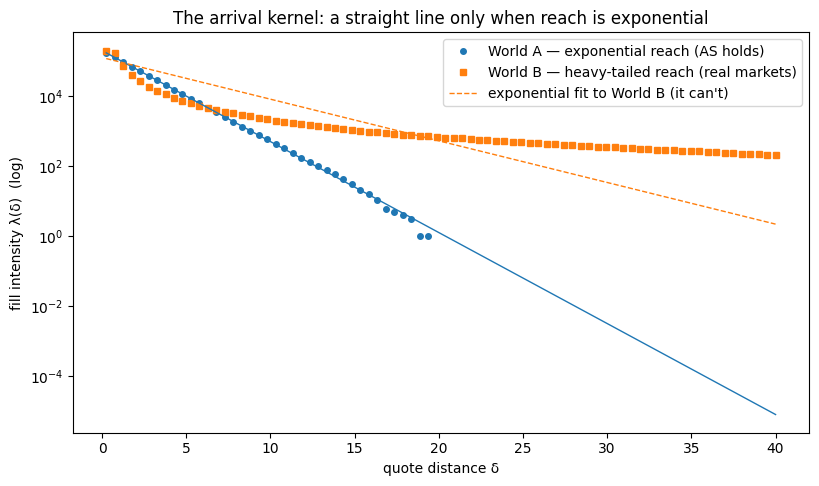

World B fits a straight exponential with R² = 0.736 — the points curve away from it.


In [2]:
# The money figure: the arrival kernel on a log axis. Exponential reach -> a straight line
# (AS holds). Heavy-tailed reach -> a curve the exponential cannot fit.
d = ex.default_deltas()
ca = sim.fill_counts(sim.WORLD_A, d, n_orders=NORD, seed=0)
cb = sim.fill_counts(sim.WORLD_B, d, n_orders=NORD, seed=0)
fa, fb = estimator.fit_exponential(d, ca), estimator.fit_exponential(d, cb)
fig, ax = plt.subplots()
ma, mb = ca > 0, cb > 0
ax.semilogy(d[ma], ca[ma], "o", ms=4, label="World A — exponential reach (AS holds)")
ax.semilogy(d[mb], cb[mb], "s", ms=4, label="World B — heavy-tailed reach (real markets)")
ax.semilogy(d, fa["A"] * np.exp(-fa["k"] * d), "-", lw=1, color="C0")
ax.semilogy(d, fb["A"] * np.exp(-fb["k"] * d), "--", lw=1, color="C1",
            label="exponential fit to World B (it can't)")
ax.set_xlabel("quote distance δ"); ax.set_ylabel("fill intensity λ(δ)  (log)")
ax.set_title("The arrival kernel: a straight line only when reach is exponential")
ax.legend(); plt.show()
print("World B fits a straight exponential with R² =", round(fb["r2"], 3),
      "— the points curve away from it.")


The exponential is the wrong *shape* for realistic flow. Scored head-to-head against a power law (heavy-tailed), the exponential wins in World A and **loses** in World B (the table also carries a clearly-labelled *stress* row, α=1.2 — heavier than any tail the study measured — which says the same thing louder):

> 🔬 **For the quants** — the verdict columns come from a per-order likelihood test: exponential vs power-law MLE on the raw execution depths, each order counted exactly once, scored by AIC and Vuong's non-nested statistic. On this notebook's 200k-order draw, World B prefers the power law by **~0.83 nats per order** (AIC gap ≈ +332k, Vuong V ≈ +171). And this isn't only a simulator artefact: the same **Clauset–Shalizi–Newman + Vuong** machinery on **real Binance order books** (4 markets, [`docs/results_real.md`](../docs/results_real.md)) calls order size power-law on **4/4** and price-distance on **3/4** — and World B's tail exponent (1.7) is drawn from the band those books measure.

In [3]:
gof = ex.kernel_gof_table(n_orders=NORD, seed=0)
print(gof.to_string())

                     r2_exp r2_pow  k_exp alpha_mle       aic_gap ll_per_order           V       winner
A (textbook)         1.0000 0.7558 0.5984    0.0711 -825,948.3000      -2.0649 -1,069.9000  exponential
B (frictions)        0.7363 0.8919 0.2739    1.7023  331,652.2000       0.8291    171.1000    power-law
B-stress (alpha=1.2) 0.6812 0.9996 0.1980    1.2016  407,572.2000       1.0189     35.8000    power-law


And because real `k` drifts through the day (the write-up admits 3–5×), a single fixed `k` mis-prices the 'optimal' spread — by **~41%** at the session length this study actually trades (T=600), and up to ~163% in the short-horizon worst case (T=1, where the `k`-term is the whole spread — quoted only as a bound):

In [4]:
ki = ex.k_instability(seed=0)
print('true k per regime           :', ki['k_true'])
print('one static k AS uses        :', ki['k_pooled_static'])
print('spread error / regime (T=600):', ki['spread_pct_error_per_regime'], '%')
print('worst spread error (T=600)  :', ki['max_abs_spread_pct_error'], '%')
print('worst case at T=1 (bound)   :', ki['bound_T1']['max_abs_spread_pct_error'], '%')

true k per regime           : [0.3, 0.6, 0.9, 1.2]
one static k AS uses        : 0.4247
spread error / regime (T=600): [-14.45, 14.53, 30.71, 41.05] %
worst spread error (T=600)  : 41.05 %
worst case at T=1 (bound)   : 162.53 %


## 5 · The Verdict — and the twist

So the assumption is false. Does the model collapse? **No — and that's the interesting part.** We run four market-makers through each world: full AS, AS with rolling volatility (the recommended 'production fix'), a plain symmetric quoter, and a *brainless inventory clamp* (no maths — just stop buying when you're too long).

In [5]:
for w in (sim.WORLD_A, sim.WORLD_B):
    t = ex.tournament(w, n_steps=NSTEP, seed=0)
    print(f'--- World {w.name} ---')
    print(t[['pnl_sharpe', 'inv_std', 'n_adverse']].to_string()); print()

--- World A (textbook) ---
                     pnl_sharpe  inv_std  n_adverse
AS (fixed)               3.1700   0.8000     0.0000
AS (adaptive vol)        3.2020   0.8100     0.0000
Symmetric (no skew)      3.4730  18.1700     0.0000
Inventory clamp          4.7500  12.3600     0.0000



--- World B (frictions) ---
                     pnl_sharpe  inv_std  n_adverse
AS (fixed)               2.0890   0.8300 2,445.0000
AS (adaptive vol)        0.1750   0.1000    35.0000
Symmetric (no skew)      0.1880  26.3600 1,338.0000
Inventory clamp          0.4430  11.3100 1,293.0000



Read those two tables:

- **World A (calm):** the brainless **clamp wins** on risk-adjusted P&L. AS works hard to pin inventory to zero — a risk nobody was paying for in a calm market.
- **World B (jumps + informed flow):** full **AS wins** decisively — *even though* its `k` is the wrong number — because keeping inventory tiny really matters when the price jumps. And the 'rolling-vol' fix **collapses** (look at its Sharpe): one jump spikes its volatility estimate and it stops trading.

The punchline: the part of AS that works (the inventory **skew**) has **no `k` in it**. The phantom kernel only corrupts the spread *width* — the half the article spends all its time on.

> 🔬 **For the quants** — it's algebra, not luck: `r = s − q·γ·σ²·(T−t)` contains no `k`; `k` enters *only* the spread's arrival term `(2/γ)·ln(1+γ/k)`. So a misspecified `k` shifts quote *width* (a level effect on fill rate) but leaves the inventory skew — the thing driving `q`→0 — untouched. That's why World-B AS keeps its tight control and positive Sharpe with `k` off by ~2.2×. The deep-dive notebook proves it by **ablation**: swap the carefully fitted phantom `k` for the plain textbook value and AS's World-B Sharpe doesn't move — the broken half wasn't doing the work.

## 6 · Could You Trade It?

Implement the **skew** — it's cheap, robust, and genuinely pays where inventory is dangerous (crypto, exactly the article's venue). Treat the **spread formula** as a rough heuristic, not a theorem: its `k` is a phantom and a sensible fixed width gets most of the way there. And don't reach for naive rolling-vol without a circuit breaker, or the first jump empties your book.

## 7 · Going Further

The one thing the simulator *asserts* — that real order reach is heavy-tailed — we already **confirmed** on four real Binance order books ([`examples/confirm_heavy_tail.py`](../examples/confirm_heavy_tail.py) → [`docs/results_real.md`](../docs/results_real.md)): order flow is power-law, not exponential. We also already **worked one complement**: does a *jump-robust* (bipower) volatility estimate rescue the collapsing rolling-vol 'production fix'? Answer — **no, only mitigated** (see [`docs/extension.md`](../docs/extension.md)): it lifts the collapsed Sharpe but stays far below plain fixed-σ AS, because adapting spread *width* is the wrong lever. The natural next steps are a **multi-day, multi-venue** real-data sweep and the **GLT** hard-inventory-bound quoter vs the brainless clamp. The deep-dive notebook (`02_for_the_quants`) carries the inference, the AIC, and the seed-robustness. **Fork it, break it, PR a better test.**